<a href="https://colab.research.google.com/github/saeidsaadatigero/AI_ML_Computer-Vision/blob/main/33_Evaluating_a_Hypothesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== مدل کوچک (High Bias) ===
Epoch 0: Train loss: 0.6300 | Val loss: 0.5370
Epoch 50: Train loss: 0.2686 | Val loss: 0.2429
Epoch 100: Train loss: 0.1664 | Val loss: 0.1337
Epoch 150: Train loss: 0.1628 | Val loss: 0.1251
Epoch 200: Train loss: 0.1612 | Val loss: 0.1235
Epoch 250: Train loss: 0.1597 | Val loss: 0.1283


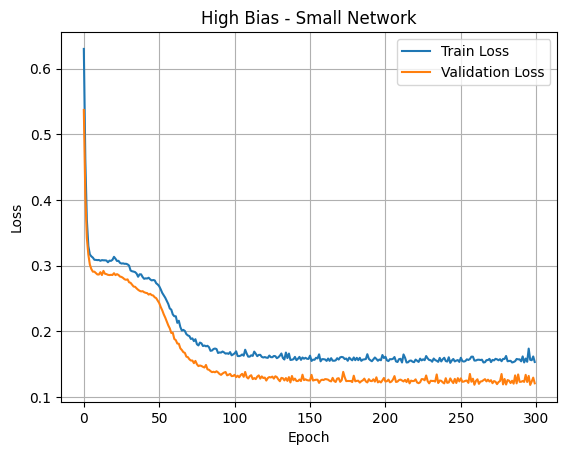


=== مدل بزرگ (High Variance) ===


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x128 and 2x128)

In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# دیتاست معروف دو هلال (non-linear و پر سر و صدا)
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X = torch.FloatTensor(X)
y = torch.LongTensor(y)

# تقسیم داده (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# مدل خیلی کوچک → High Bias (underfit
class SmallNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),   # فقط ۴ نود!
            nn.ReLU(),
            nn.Linear(4, 2)
        )
    def forward(self, x):
        return self.net(x)

# مدل خیلی بزرگ → High Variance (overfit)
class BigNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

def train_and_plot(model_class, title):
    model = model_class()
    model = model_class()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)

    for epoch in range(300):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                out = model(batch_x)
                val_loss += criterion(out, batch_y).item()
        val_losses.append(val_loss / len(val_loader))

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train loss: {train_losses[-1]:.4f} | Val loss: {val_losses[-1]:.4f}")

    # رسم Learning Curve
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# اجرا کن
print("=== مدل کوچک (High Bias) ===")
train_and_plot(SmallNN, "High Bias - Small Network")

print("\n=== مدل بزرگ (High Variance) ===")
train_and_plot(BigNN, "High Variance - Big Network")